TASK: LOGISTIC REGRESSION - BANK CUSTOMER CHURN PREDICTION
Dataset: Bank Customer Churn Dataset (Kaggle - gauravtopre/bank-customer-churn-dataset)
Goal: Predict whether a customer will churn (leave) ABC Bank, identify the
      relevant features driving churn, and evaluate model performance.

In [11]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

os.makedirs("plots", exist_ok=True)

In [12]:
# ----------------------------------------------------------------------
# 1. LOAD DATASET
# ----------------------------------------------------------------------
import kagglehub

churn_path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")
file_name = [f for f in os.listdir(churn_path) if f.endswith('.csv')][0]
df_churn = pd.read_csv(os.path.join(churn_path, file_name))

print("Data loaded. Shape:", df_churn.shape)
print(df_churn.columns.tolist())

100%|██████████| 187k/187k [00:00<00:00, 351kB/s]

Extracting files...
Data loaded. Shape: (10000, 12)
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']



=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None

=== MISSING VALUES ===
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure   

/tmp/ipykernel_1165/3209995982.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df_churn, palette='Set2')


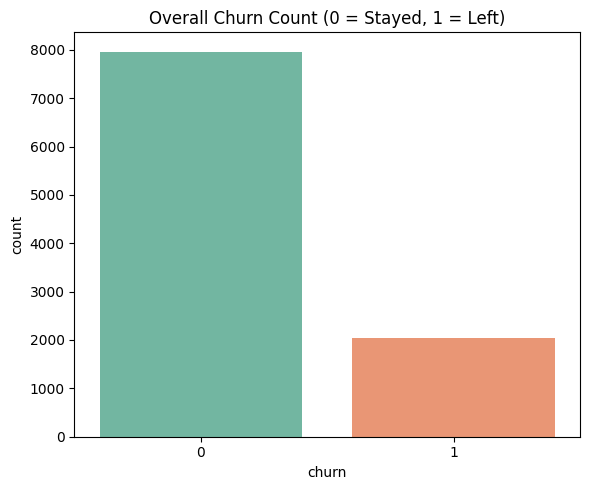

/tmp/ipykernel_1165/3209995982.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='age', data=df_churn, ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_1165/3209995982.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='balance', data=df_churn, ax=axes[1, 2], palette='Set2')


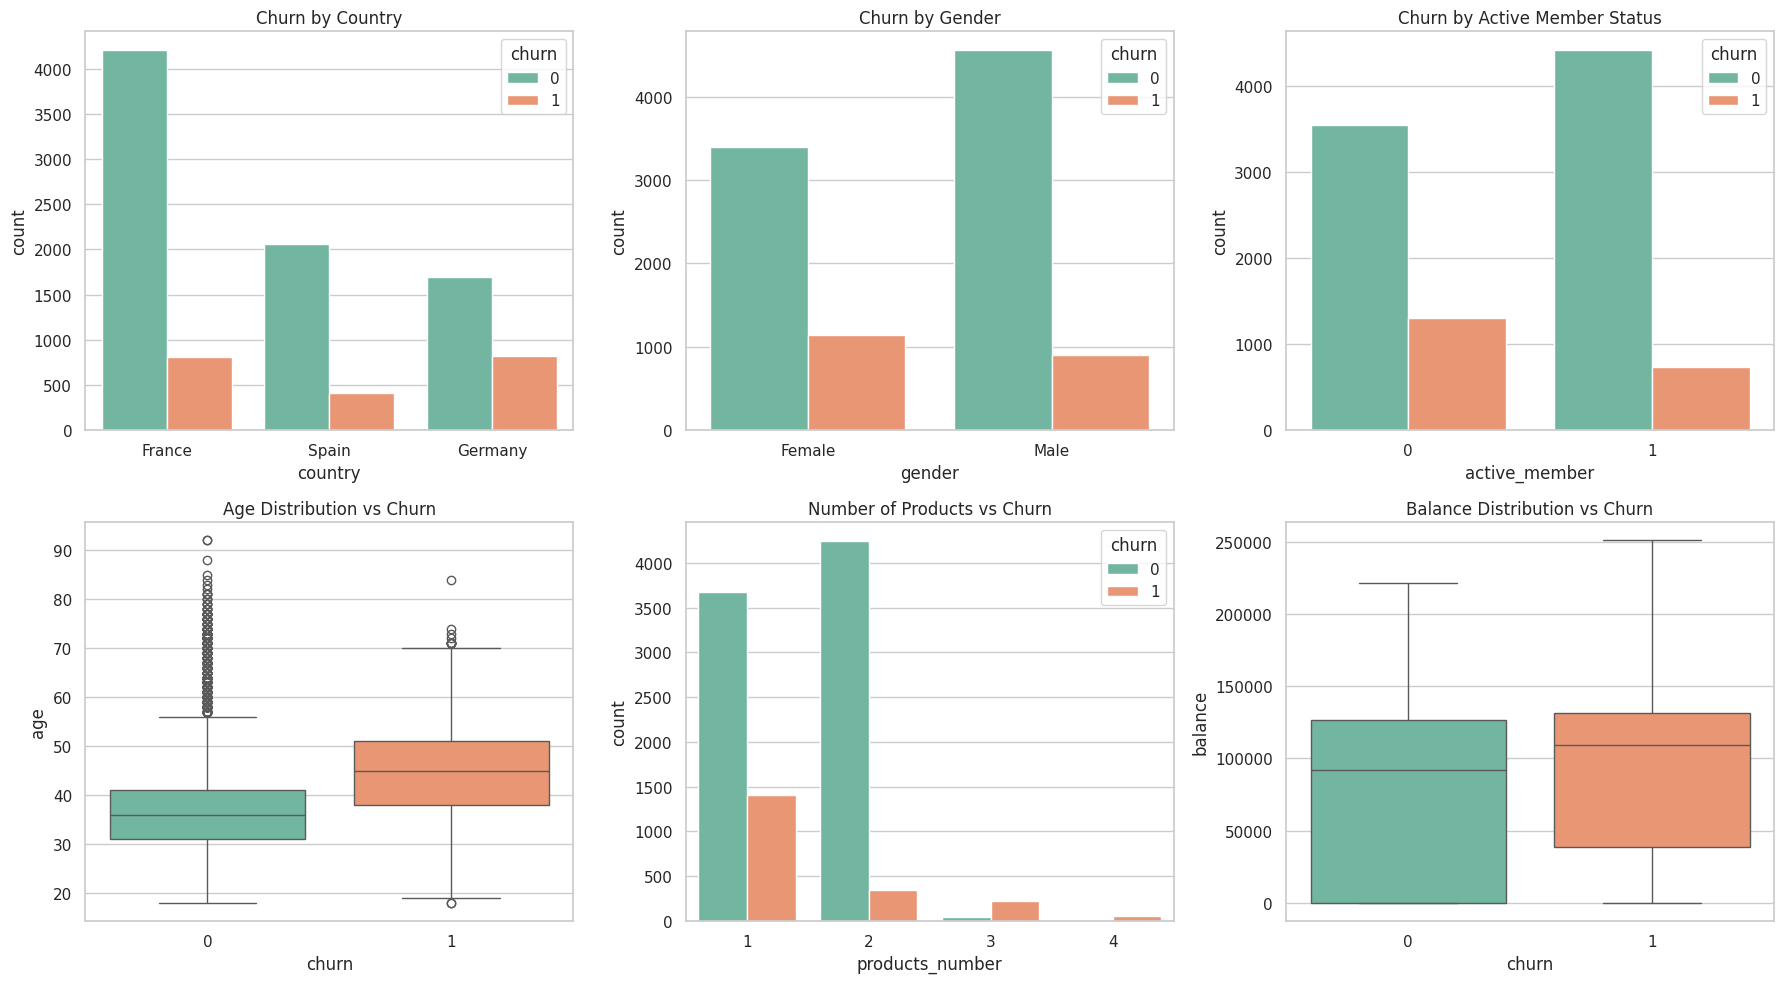

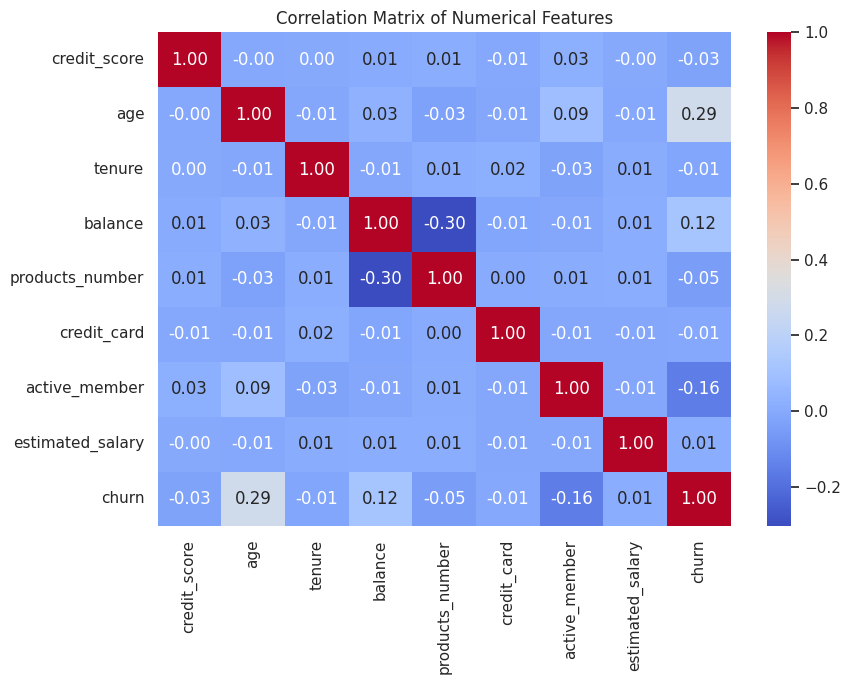


--- Correlation with Churn ---
churn               1.000000
age                 0.285323
balance             0.118533
estimated_salary    0.012097
credit_card        -0.007138
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
active_member      -0.156128
Name: churn, dtype: float64


In [13]:

# ----------------------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ----------------------------------------------------------------------
print("\n=== DATASET INFO ===")
print(df_churn.info())

print("\n=== MISSING VALUES ===")
print(df_churn.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print(f"Duplicates: {df_churn.duplicated().sum()}")

print("\n=== FIRST 5 ROWS ===")
print(df_churn.head())

print("\n=== SUMMARY STATISTICS ===")
print(df_churn.describe())

churn_pct = df_churn['churn'].mean() * 100
print(f"\nOverall Churn Rate: {churn_pct:.2f}%")

# a) Target class distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='churn', data=df_churn, palette='Set2')
plt.title('Overall Churn Count (0 = Stayed, 1 = Left)')
plt.tight_layout()
plt.savefig("plots/B_churn_distribution.png")
plt.show()

# b) EDA grid: churn by key categorical / numerical features
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(x='country', hue='churn', data=df_churn, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Churn by Country')

sns.countplot(x='gender', hue='churn', data=df_churn, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Churn by Gender')

sns.countplot(x='active_member', hue='churn', data=df_churn, ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Churn by Active Member Status')

sns.boxplot(x='churn', y='age', data=df_churn, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Age Distribution vs Churn')

sns.countplot(x='products_number', hue='churn', data=df_churn, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Number of Products vs Churn')

sns.boxplot(x='churn', y='balance', data=df_churn, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Balance Distribution vs Churn')

plt.tight_layout()
plt.savefig("plots/B_eda_grid.png")
plt.show()

# c) Correlation heatmap (numeric features only)
plt.figure(figsize=(9, 7))
numeric_df = df_churn.select_dtypes(include=[np.number]).drop(columns=['customer_id'], errors='ignore')
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig("plots/B_correlation_heatmap.png")
plt.show()
print("\n--- Correlation with Churn ---")
print(corr['churn'].sort_values(ascending=False))

In [14]:

# ----------------------------------------------------------------------
# 3. DATA PREPROCESSING
# ----------------------------------------------------------------------
df_proc = df_churn.drop(columns=['customer_id'])

X = df_proc.drop(columns=['churn'])
y = df_proc['churn']

# One-hot encode categorical text features (country, gender)
X_encoded = pd.get_dummies(X, drop_first=True)

# Stratified train-test split (keeps churn ratio balanced in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nPreprocessing complete. Features used:", list(X_encoded.columns))


Preprocessing complete. Features used: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male']


In [15]:

# ----------------------------------------------------------------------
# 4. MODEL - LOGISTIC REGRESSION
# ----------------------------------------------------------------------
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# 5-fold cross validation
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"\nCross-Validation ROC-AUC scores: {cv_scores}")
print(f"Cross-Validation ROC-AUC (mean): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Feature coefficients & odds ratios
coef_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds_Ratio': np.exp(log_reg.coef_[0])
}).sort_values(by='Coefficient', ascending=False)

print("\n================== LOGISTIC REGRESSION FEATURE COEFFICIENTS ==================")
print(coef_df)



Cross-Validation ROC-AUC scores: [0.76971232 0.76236384 0.75754592 0.7806917  0.74648708]
Cross-Validation ROC-AUC (mean): 0.7634 (+/- 0.0115)

================== LOGISTIC REGRESSION FEATURE COEFFICIENTS ==================
             Feature  Coefficient  Odds_Ratio
1                age     0.738847    2.093520
8    country_Germany     0.356679    1.428578
3            balance     0.160622    1.174241
7   estimated_salary     0.047725    1.048882
9      country_Spain     0.018907    1.019087
2             tenure    -0.020071    0.980129
5        credit_card    -0.032208    0.968306
4    products_number    -0.070292    0.932122
0       credit_score    -0.085986    0.917607
10       gender_Male    -0.260851    0.770396
6      active_member    -0.515485    0.597211



================== TEST SET PERFORMANCE METRICS ==================
Accuracy  : 0.8080
Precision : 0.5891
Recall    : 0.1867
F1-Score  : 0.2836
ROC-AUC   : 0.7748

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



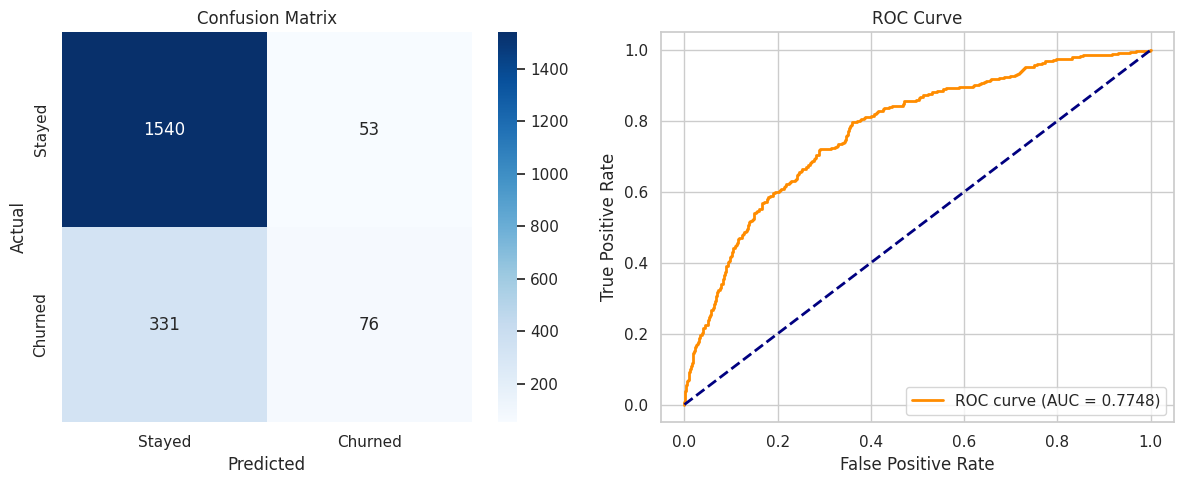

/tmp/ipykernel_1165/1394213188.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')


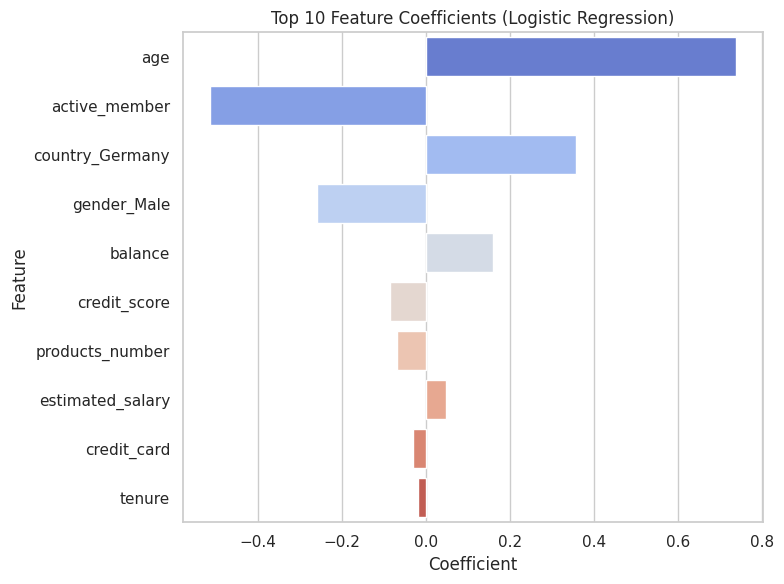


All plots saved in the 'plots/' folder.

================== SUMMARY ==================
Top drivers of churn (by |coefficient|):
             Feature  Coefficient  Odds_Ratio
1                age     0.738847    2.093520
6      active_member    -0.515485    0.597211
8    country_Germany     0.356679    1.428578
10       gender_Male    -0.260851    0.770396
3            balance     0.160622    1.174241
0       credit_score    -0.085986    0.917607
4    products_number    -0.070292    0.932122
7   estimated_salary     0.047725    1.048882
5        credit_card    -0.032208    0.968306
2             tenure    -0.020071    0.980129


In [16]:

# ----------------------------------------------------------------------
# 5. MODEL EVALUATION
# ----------------------------------------------------------------------
print("\n================== TEST SET PERFORMANCE METRICS ==================")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# a) Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f"ROC curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})")
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig("plots/B_confusion_matrix_roc.png")
plt.show()

# b) Feature importance plot (top 10 by absolute coefficient)
top_features = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index).head(10)
plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_features, palette='coolwarm')
plt.title('Top 10 Feature Coefficients (Logistic Regression)')
plt.tight_layout()
plt.savefig("plots/B_feature_importance.png")
plt.show()

print("\nAll plots saved in the 'plots/' folder.")
print("\n================== SUMMARY ==================")
print("Top drivers of churn (by |coefficient|):")
print(top_features[['Feature', 'Coefficient', 'Odds_Ratio']])